In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal


data = np.loadtxt("notebook/data/itmx_z_1441947618.txt")
data_dt = 1/512  # Data sampling rate
dt = 1/64  # Downsampled rate
q = int(dt/data_dt)  # Downsampling factor

y = scipy.signal.decimate(data, q)
y = y-np.mean(y)

t = np.arange(0, dt*len(y), dt)

fs = 1/dt  # Sampling frequency in Hz
lowcut = 0.05 # Low cutoff frequency in Hz
highcut = 0.5 # High cutoff frequency in Hz
N = 4 # Filter order

sos = scipy.signal.butter(N, (lowcut, highcut), btype='bandpass', fs=fs, output='sos')

y_ = scipy.signal.sosfiltfilt(sos, y)

# f, pyy = scipy.signal.welch(y, fs=1/dt, nperseg=int(len(y)/10))
# f, pyy_ = scipy.signal.welch(y_, fs=1/dt, nperseg=int(len(y_)/10))

# ayy = pyy**.5
# ayy_ = pyy_**.5

# plt.loglog(f, ayy)
# plt.loglog(f, ayy_)

# plt.plot(t[0:6400], y[0:6400])
# plt.plot(t[0:6400], y_[0:6400])

In [2]:
n_train = int(1/dt*10)  # 10 seconds
# print(n_train)
n_test = int(len(y_)*0.2)

data_train = y_[0:n_train]
data_test = y_[n_train:n_test+n_train]

In [6]:
season_length = int(1/dt/0.2)  # sampling rate divided by frequency
alpha = 0.4  # level smoothing parameter
beta = 0.2  # trend smoothing parameter
gamma = 0.3  # seasonal smoothing parameter
n_forecast = int(1/dt) # 1 second divided by sampling time.

fitted, forecast = holt_winters_additive(data_train, season_length, alpha, beta, gamma, n_forecast)

In [17]:
import seisim.predictor

order = 2
n_forecast = 1

full_predict = np.zeros_like(y_)
predictor = seisim.predictor.ConstantOrder(dt=dt, order=2, n_forecast=n_forecast)


for i in range(order+1, len(y_)):
    predict = predictor.run(y_[i-order-1:i])
    full_predict[i] = predict
# predict = predictor.run(data_train)
# fitted_last, acc_forecast = constant_order_forecast(data_train[-10:], dt=dt, order=9, n_forecast=n_forecast)

In [4]:
len(y_[-10:])

10

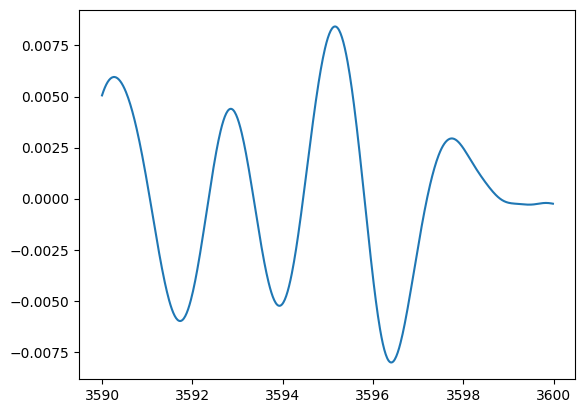

In [23]:
# plt.plot(t, full_predict)
plt.plot(t[-640:], (y_-full_predict)[-640:])

In [13]:
for i in range(1,3):
    print(i)

1
2


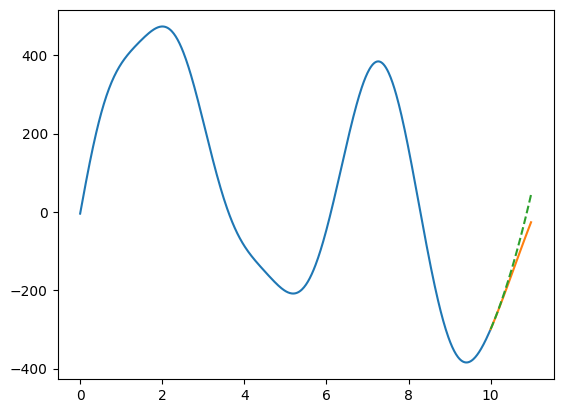

In [11]:
plt.plot(t[:len(data_train)], data_train)
# plt.plot(t[:len(data_train)], fitted)
plt.plot(t[len(data_train):len(data_train)+len(forecast)], data_test[:len(forecast)], "-")
# plt.plot(t[len(data_train):len(data_train)+len(forecast)], forecast, "--")
plt.plot(t[len(data_train):len(data_train)+len(forecast)], predict, "--")
# plt.
# plt.plot

In [139]:
y = np.array([
    10, 12, 13, 12,
    11, 13, 14, 13,
    12, 14, 15, 14
])

fitted, forecast = holt_winters_additive(
    y,
    season_length=4,
    alpha=0.4,
    beta=0.2,
    gamma=0.3,
    n_forecast=4
)

fitted_last, pred = constant_order_forecast(y, dt=1, order=2, n_forecast=4)
x = np.arange(len(y))

In [26]:
x2 = np.arange(len(forecast))+x[-1]+1
x2

array([12, 13, 14, 15])

In [111]:
pred[:, 0]

array([ 31.08903116,  88.47549784, 244.7843405 , 675.59522848])

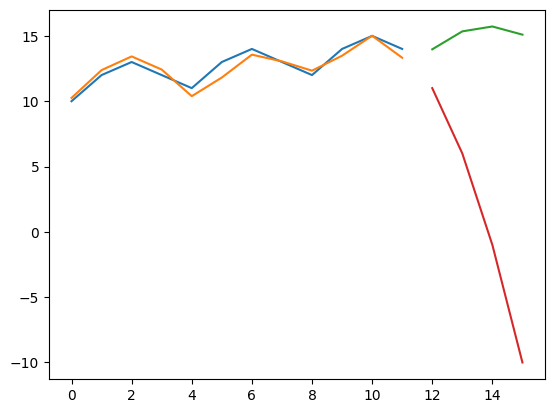

In [142]:
plt.plot(x, y)
plt.plot(x, fitted)

plt.plot(x2, forecast)
plt.plot(x2, pred)

In [5]:
def holt_winters_additive(
    y,
    season_length,
    alpha,
    beta,
    gamma,
    n_forecast=1
):
    """
    Holt-Winters additive model.

    Parameters
    ----------
    y : array-like
        Time series data
    season_length : int
        Number of points per season
    alpha : float
        Level smoothing parameter (0 < alpha < 1)
    beta : float
        Trend smoothing parameter (0 < beta < 1)
    gamma : float
        Seasonal smoothing parameter (0 < gamma < 1)
    n_forecast : int
        Number of future points to forecast

    Returns
    -------
    fitted : np.ndarray
        In-sample fitted values
    forecast : np.ndarray
        Out-of-sample forecast
    """

    y = np.asarray(y)
    n = len(y)

    # --- Initialization ---
    level = y[0]
    trend = (y[season_length] - y[0]) / season_length
    seasonals = np.zeros(season_length)

    for i in range(season_length):
        seasonals[i] = y[i] - level

    fitted = np.zeros(n)

    # --- Main loop ---
    for t in range(n):
        if t >= season_length:
            s = seasonals[t % season_length]
        else:
            s = seasonals[t]

        fitted[t] = level + trend + s

        y_t = y[t]

        prev_level = level
        prev_trend = trend
        prev_season = s

        level = alpha * (y_t - prev_season) + (1 - alpha) * (prev_level + prev_trend)
        trend = beta * (level - prev_level) + (1 - beta) * prev_trend
        seasonals[t % season_length] = (
            gamma * (y_t - level) + (1 - gamma) * prev_season
        )

    # --- Forecast ---
    forecast = np.zeros(n_forecast)
    for h in range(1, n_forecast + 1):
        forecast[h - 1] = (
            level
            + h * trend
            + seasonals[(n + h - 1) % season_length]
        )

    return fitted, forecast

In [176]:
%%timeit
math.factorial(10)

52.1 ns ± 1.63 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [175]:
%%timeit
scipy.special.factorial(10, exact=True)

1.85 µs ± 66.6 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [161]:
import numpy as np
import math

def constant_order_forecast(
    y, dt, order, n_forecast
):
    """
    Constant N-th derivative predictor from a time series.

    Parameters
    ----------
    y : array-like
        Input time series (uniformly sampled)
    dt : float
        Time step
    order : int
        Model order:
            0 = constant
            1 = constant velocity
            2 = constant acceleration
            ...
    n_forecast : int
        Number of points to forecast

    Returns
    -------
    fitted_last : float
        One-step-ahead fitted value at last sample
    forecast : np.ndarray
        Forecasted values
    """

    y = np.asarray(y, dtype=float)
    n = len(y)

    if n < order + 1:
        raise ValueError("Not enough data for requested order")

    # --- Fit local polynomial to last points ---
    t = np.arange(-(order), 1) * dt
    coeffs = np.polyfit(t, y[-(order+1):], order)

    # --- Extract derivatives at t=0 ---
    # poly: c0*t^N + ... + cN
    state = np.zeros(order + 1)
    for k in range(order + 1):
        state[k] = math.factorial(k) * coeffs[-(k+1)]

    # --- Build state transition matrix ---
    F = np.zeros((order + 1, order + 1))
    for i in range(order + 1):
        for j in range(i, order + 1):
            F[i, j] = dt**(j - i) / math.factorial(j - i)

    # --- One-step-ahead fit ---
    fitted_last = (F @ state)[0]

    # --- Forecast ---
    forecast = np.zeros(n_forecast)
    x = state.copy()
    for k in range(n_forecast):
        x = F @ x
        forecast[k] = x[0]

    return fitted_last, forecast